**Notebook por:** MSc. Eng. Paulo Silva  
**Data** Julho de 2026

# **J-PIKAN**

Para citar os autores
```bibtex
@article{xiong2025j,
  title={J-PIKAN: A Physics-Informed KAN Network Based on Jacobi Orthogonal Polynomials for solving Fluid Dynamics},
  author={Xiong, Xiong and Lu, Kang and Zhang, Zhuo and Zeng, Zheng and Zhou, Sheng and Deng, Zichen and Hu, Rongchun},
  journal={Communications in Nonlinear Science and Numerical Simulation},
  pages={109414},
  year={2025},
  publisher={Elsevier}
}
```

## **1. Introdução**

### Contexto e Limitações Atuais
* As PINNs tradicionais, construídas com arquiteturas MLPs, enfrentam limitações ao resolver problemas não-lineares complexos.
* Os desafios incluem:
  * dificuldades de otimização,
  * viés espectral, e
  * eficiência limitada de parâmetros.
* Tais problemas frequentemente se manifestam como **mau condicionamento** durante o treinamento, o que pode comprometer a convergência.



---

### Abordagem KAN e J-PIKAN
* As Redes de Kolmogorov-Arnold (KANs) propõem uma mudança estrutural: substituem **funções de ativação fixas** por funções aprendíveis.
* KANs baseadas em *B-splines* (modelo original) mostraram-se ineficientes e com precisão relativamente baixa para a tarefa específica de resolver EDPs.
* Para superar isso, os autores propõem a **J-PIKAN**, que utiliza **polinômios ortogonais de Jacobi** como funções de ativação.

---
> Como resultado, a J-PIKAN alcança de 1 a 2 ordens de grandeza em melhoria de precisão utilizando 50% menos parâmetros que as MLPs em benchmarks de dinâmica dos fluidos.

---

### **Formulação Geral do Problema**
EDPs não lineares, sujeitas a condições iniciais e de contorno, são descritas por:

$$
\begin{align*}
F_{\theta}[u](\mathbf{x}) = & \ f(\mathbf{x}), \quad  \mathbf{x} \in \Omega \\
B_{\theta}[u](\mathbf{x}) = & \ b(\mathbf{x}), \quad  \mathbf{x} \in  \partial\Omega \\
I_{\theta}[u](\mathbf{x}) = & \ g(\mathbf{x}), \quad  \mathbf{x} \in  \Omega_{0}
\end{align*}
$$

Onde:
* $\mathbf{x}$ representa as coordenadas espaço-temporais e $u$ é a solução aproximada pela rede neural ($u_{\theta}$) parametrizada por $\theta$.
* $F$ e $B$ são operadores **diferenciais** e de **contorno** não-lineares, e $I$ é o operador de **condição inicial**.
* $f$ é o termo fonte, $b$ é o termo de contorno e $g$ é a condição inicial.
* O domínio $\Omega$ é limitado, com contorno $\partial\Omega$ e domínio espacial inicial $\Omega_{0}$.

## **2. Polinômios de Jacobi**

Para estruturar a nova função de ativação da KAN, o estudo fundamenta-se nos polinômios de Jacobi.

### **Definição e Propriedades Fundamentais**
* Os polinômios de Jacobi, denotados como $J_{n}^{(\alpha,\beta)}(x)$, formam uma base completa em espaços $L^{2}$ ponderados.

* São definidos no intervalo finito $[-1, 1]$ com parâmetros ajustáveis $\alpha, \beta > -1$.

$$\int_{-1}^1 (1 - x)^\alpha (1+x)^\beta J_{m}^{(\alpha,\beta)}(x) J_{n}^{(\alpha,\beta)}(x) dx = \dfrac{2^{\alpha + \beta + 1}}{2n + \alpha + \beta + 1} \dfrac{\Gamma(n+\alpha+1) \Gamma(n+\beta+1)}{\Gamma(n+\alpha+\beta+1)n!}\delta_{nm}$$

### **Relação de Recorrência**
Uma característica dos polinômios de Jacobi é que eles podem ser gerados através de uma relação de recorrência de três termos:

$$J_{n}^{(\alpha,\beta)}(x) = (A_{n}x + B_{n})J_{n-1}^{(\alpha,\beta)}(x) + C_{n}J_{n-2}^{(\alpha,\beta)}(x)$$

*Onde $A_n$, $B_n$ e $C_n$ são coeficientes dependentes do grau $n$ e dos parâmetros $\alpha$ e $\beta$* expressos por:

$$
\begin{align*}
A_n = & \ \dfrac{(2n+\alpha + \beta+1)(2n+\alpha + \beta)}{2n(n+\alpha + \beta)}\\
B_n = & \ \dfrac{(2n+\alpha + \beta-1)(\alpha^2 - \beta^2)}{2n(n+\alpha + \beta)(2n+\alpha + \beta-2)}\\
C_n = & \ \dfrac{-2(n+\alpha-1)(n+\beta-1)(2n+\alpha + \beta)}{2n(n+\alpha + \beta)(2n+\alpha + \beta-2)}
\end{align*}
$$

Os termos iniciais para a construção da série são definidos como:
$$J_{0}^{(\alpha,\beta)}(x) = 1 \hspace{2cm} J_{1}^{(\alpha,\beta)}(x) = \frac{\alpha+\beta+2}{2}x + \frac{\alpha-\beta}{2}$$

### **Casos Especiais**
Os parâmetros $\alpha$ e $\beta$ permitem que os polinômios de Jacobi se reduzam a outras famílias de polinômios conhecidas:
* **Polinômios de Legendre:** Quando $\alpha = \beta = 0$.
$$
\begin{align*}
P_0(x) = & \ 1 \hspace{2cm} P_1(x) =  \ x \\
(n + 1)P_{n+1}(x) = & \ (2n + 1)xP_n(x) - nP_{n-1}(x), \quad n \geq 1.
\end{align*}
$$

* **Polinômios de Chebyshev (primeira espécie):** Quando $\alpha = \beta = -0.5$.
$$
\begin{align*}
T_0(x) = & \ 1 \hspace{2cm} T_1(x) =  \ x \\
T_{n+1}(x) = & \ 2xT_n(x) - T_{n-1}(x), \quad n \geq 1.
\end{align*}
$$

---

## **3. A Arquitetura J-PIKAN**

### **Teorema de Kolmogorov-Arnold**
Segundo o teorema, qualquer função contínua de múltiplas variáveis pode ser representada como uma superposição de funções univariadas contínuas:

$$u_{\theta}(x_1, x_2, \dots, x_n) = \sum_{i=1}^{2n+1} \Phi_i \left( \sum_{j=1}^n \phi_{ij}(x_j) \right)$$

Diferente das MLPs, que utilizam funções de ativação fixas nos nós, as redes KAN utilizam funções univariadas aprendíveis nas arestas.

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Jpikan_net.png" alt = "Diagrama da Arquitetura do J-PIKAN." width="900"><br>
  <em>Diagrama da Arquitetura do J-PIKAN</em>
</div>


---

### **Camada JacobiKAN**
O artigo propõe substituir as *B-splines* por uma expansão em polinômios de Jacobi. Para uma rede profunda com $L$ camadas, cada função univariada é definida como:

$$\boxed{\phi_{ij}^{(l)}(x) = \sum_{n=0}^N c_{n,ij}^{(l)} J_n^{(\alpha, \beta)}(\tanh(x))}$$

Onde:
* $c_{n,ij}^{(l)}$ são os coeficientes treináveis
* $N$ é o grau máximo do polinômio
* A função $\tanh(x)$ atua como um normalizador para garantir que as entradas permaneçam estritamente dentro do intervalo de ortogonalidade $[-1, 1]$

A rede profunda final é expressa pela composição de múltiplas camadas:
$$u_{\theta}(\mathbf{x}) = \Phi^{(L-1)} \circ \Phi^{(L-2)} \circ \dots \circ \Phi^{(0)}(\mathbf{x})$$

---

### ***Loss Function* e Otimização**
A rede utiliza Diferenciação Automática para construir a função de perda física, composta pelos resíduos da EDP, condições iniciais (IC) e condições de contorno (BC):

$$\mathcal{L}_{J-PIKAN}(\theta) = \lambda_{IC}\mathcal{L}_{IC}(\theta) + \lambda_{BC}\mathcal{L}_{BC}(\theta) + \lambda_{PDE}\mathcal{L}_{PDE}(\theta)$$

cada componente é definido como segue:
$$
\begin{align*}
\mathcal{L}_{PDE}(\theta) = & \ \frac{1}{N_f} \sum_{j=1}^{N_f} ||(F_\theta [u_\theta](x_j^f)-f_j)||^2, \\
\mathcal{L}_{BC}(\theta) = & \ \frac{1}{N_b} \sum_{l=1}^{N_b} ||(B_\theta [u_\theta](x_l^b)-b_l)||^2, \\
\mathcal{L}_{IC}(\theta) = & \ \frac{1}{N_i} \sum_{k=1}^{N_i} ||(I_\theta [u_\theta](x_k^i)-g_k)||^2. \\
\end{align*}
$$

> Os autores consideraram no estudo $\lambda_{IC} = \lambda_{BC} = \lambda_{PDE} = 1$

**Estratégia de Treinamento em Dois Estágios:**  
Para otimizar os pesos, os autores adotaram a seguinte abordagem:
1. **Otimizador Adam:** Utilizado no primeiro estágio para uma busca global, superando mínimos locais.
2. **Otimizador L-BFGS:** Aplicado no segundo estágio (método quasi-Newton) para refinamento local de alta precisão, acelerando a convergência próximo da solução ótima.

---

## **4. Análise Empírica de Otimização de Características na J-PIKAN**

A J-PIKAN tenta mitigar o mau condicionamento numérico (*ill-conditioning*). Assim como em PINNs com MLP, o processo de treinamento da J-PIKAN pode ser descrito como sistema de fluxo de gradiente

$$\frac{d \theta}{d t}  = - \nabla_\theta \mathcal{L}_{IC}(\theta) - \nabla_\theta \mathcal{L}_{BC}(\theta) - \nabla_\theta \mathcal{L}_{PDE}(\theta)$$

* O maior autovalor da matriz Hessiana, $\sigma_{max}\nabla_{\theta}^{2}\mathcal{L}(\theta)$, determina a escala de tempo mais rápida no sistema de fluxo de gradiente e limita diretamente a taxa de aprendizado que pode ser utilizada no método do gradiente descendente.
* De acordo com a teoria da análise numérica, para garantir a estabilidade da discretização de Euler progressiva (isto é, a atualização do gradiente descendente), a taxa de aprendizado deve satisfazer a condição
$$\eta < \dfrac{2}{\sigma_{max}\nabla_{\theta}^{2}\mathcal{L}(\theta)}$$
* Quando o número de condição da matriz Hessiana é elevado, essa restrição torna-se particularmente rigorosa, exigindo taxas de aprendizado extremamente baixas durante o processo de treinamento, o que reduz significativamente a velocidade de convergência.
* Pesquisas existentes indicam que o mau condicionamento em PINNs decorre principalmente da matriz Hessiana da função de perda da EDP, na qual a distribuição dos autovalores é altamente desigual - apresentando alguns autovalores extremamente grandes e muitos próximos de zero -, resultando em um número de condição anormalmente alto.

---


Para compreender melhor a questão do mal-condicionamento numérico no modelo J-PIKAN, examinamos as variações na função de perda da EDP durante a descida do gradiente, a fim de revelar a relação entre a rigidez (*stiffness*) e a dificuldade de treinamento. Considere o n-ésimo passo de treinamento, no qual a atualização dos parâmetros ocorre da seguinte forma:

$$\theta_{n+1} = \theta_n - \eta \nabla _\theta \mathcal{L}_{PDE}(\theta_n)$$

em que $\eta$ é a taxa de aprendizado. Ao realizar uma expansão de Taylor de segunda ordem da função de perda da EDP, $\mathcal{L}_{PDE}(\theta_n)$, em torno de $\theta_n$ e combiná-la com a fórmula de atualização de parâmetros, obtemos:

$$\mathcal{L}_{PDE}(\theta_{n+1}) - \mathcal{L}_{PDE}(\theta_n) = -\eta ||\nabla_\theta \mathcal{L}_{PDE}(\theta_n)||^2_2 + \frac{1}{2}\eta^2 \nabla_\theta \mathcal{L}_{PDE}(\theta_n)^T \nabla ^2_ \theta \mathcal{L}_{PDE}(\xi) \nabla_\theta \mathcal{L}_{PDE}(\theta_n)$$

em que $\xi$ é um ponto entre $\theta_n$ e $\theta_{n+1}$. Através de uma decomposição de autovalores, a expressão anterior pode ser reescrita como

$$\mathcal{L}_{PDE}(\theta_{n+1}) - \mathcal{L}_{PDE}(\theta_n) = -\eta ||\nabla_\theta \mathcal{L}_{PDE}(\theta_n)||^2_2 \left( -1 + \frac{1}{2}\eta \sum_{i=1}^M \lambda_i ^{PDE} y_i^2 \right)  $$

em que $\lambda_i^{PDE}$ denota o i-ésimo autovalor da matriz Hessiana $\nabla ^2_ \theta \mathcal{L}_{PDE}(\xi)$, e $y_i$ representa a projeção do gradiente normalizado na direção do autovetor correspondente.


---


* Quando o fluxo de gradiente é mal condicionado, a distribuição dos autovalores da matriz Hessiana $\nabla ^2_ \theta \mathcal{L}_{PDE}(\xi)$ torna-se bastante desigual, com alguns autovalores sendo significativamente grandes.

* Em casos nos quais o maior autovalor é extremamente elevado,
observa-se que, mesmo quando η é definido com um valor pequeno, a condição $\mathcal{L}_{PDE}(\theta_{n+1}) - \mathcal{L}_{PDE}(\theta_n) > 0 $ ainda pode ocorrer, o que significa que o método de descida do gradiente não consegue reduzir efetivamente o valor da função de perda da PDE. Esse fenômeno é particularmente comum no treinamento de PINNs.

> **No modelo J-PIKAN, supõe-se que, devido às propriedades de ortogonalidade dos polinômios de Jacobi, o maior autovalor da matriz Hessiana da função de perda da PDE possa ser menor do que o observado em MLPs, o que potencialmente amenizaria o problema de mau condicionamento durante o treinamento do J-PIKAN
e permitiria uma convergência mais rápida do modelo.**  

* Essa análise sugere que as propriedades de ortogonalidade dos polinômios de Jacobi podem contribuir
para um melhor condicionamento, embora as interações complexas em redes profundas exijam investigações teóricas adicionais.

#### **Evolução dos autovalores da matriz Hessiana**

**Caso da Equação de Burgers**
<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/hessian_burgers.png" alt = "Evolução autovalores da Hessiana durante treinamento da equação de Burgers." width="900"><br>
  <em>Evolução autovalores da Hessiana durante treinamento da equação de Burgers</em>
</div>


**Caso da Equação KdV**
<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/hessian_burgers.png" alt = "Evolução autovalores da Hessiana durante treinamento da equação KdV." width="900"><br>
  <em>Evolução autovalores da Hessiana durante treinamento da equação KdV</em>
</div>

## **5. Resultados em Benchmarks de Dinâmica dos Fluidos**

Abaixo estão as formulações matemáticas e as tabelas de resultados para os problemas resolvidos pelo modelo J-PIKAN no artigo.

Algumas considerações gerais dos estudos:
* Os autores sempre utilizaram $\alpha = \beta $ (sugestão de trabalho futuro é explorar parâmetros distintos entre si)
* Foram feitos estudos de 5 problemas:
  * Burgers 1D
  * Kortewrg-de Vries (KdV)
  * Taylor-Green vortex
  * Fluido de Kovasznay (vamos explorar esse aqui)
  * Lid-driven cavity
* Estudo executado em uma GPU NVIDIA RTX 4090
---






### A. Equação de Burgers (1D Não-Linear)

**Equação e Condições:**
A Equação de Burgers modela a propagação e formação de ondas de choque não lineares.

$$u_t + uu_x - \frac{0.01}{\pi}u_{xx} = 0, \quad x \in [-1, 1], \quad t \in [0, 1]$$
$$u(0, x) = -\sin(\pi x)$$
$$u(t, -1) = u(t, 1)$$

**Resultados de Precisão:**

<div align="center">

| Modelo | Arquitetura do Modelo| Qtd. de Parâmetros | Erro Relativo Norma $L_2$ |
| :--- | :--- | :---: | :----------------: |
| **Jacobi ($\alpha=\beta=2$)** | [2, 20, 20, 1] | 2300 | $(5.8 \pm 1.7) \times 10^{-4}$ |
| Jacobi ($\alpha=\beta=1$) | [2, 20, 20, 1] | 2300 | $(1.8 \pm 0.5) \times 10^{-3}$ |
| Chebyshev | [2, 20, 20, 1] | 2300 | $(5.6 \pm 1.4) \times 10^{-3}$ |
| Legendre | [2, 20, 20, 1] | 2300 | $(5.5 \pm 1.8) \times 10^{-3}$ |
| B-spline | [2, 20, 20, 1] | 4140 | $(2.1 \pm 0.7) \times 10^{-1}$ |
| MLP Tradicional | [2, 40, 40, 40, 40, 1] | 5081 | $(5.3 \pm 1.9) \times 10^{-3}$ |

</div>

---


### B. Equação KdV (Korteweg-de Vries)

**Equação e Condições:**
A equação de KdV descreve ondas de águas rasas e soluções estáveis de sólitons com derivadas de terceira ordem.

$$u_t + 6uu_x + u_{xxx} = 0, \quad x \in [-1, 1], \quad t \in [0, 1]$$
$$u(0, x) = \cos(\pi x)$$
$$u(t, -1) = u(t, 1)$$
$$u_x(t, -1) = u_x(t, 1)$$
$$u_{xx}(t, -1) = u_{xx}(t, 1)$$

**Resultados de Precisão:**

<div align="center">

| Modelo | Arquitetura | Parâmetros | Erro Relativo Norma $L_2$ |
| :--- | :--- | :--- | :--- |
| **Legendre** | [2, 20, 20, 20, 20, 1] | 5040 | $(5.4 \pm 1.3) \times 10^{-3}$ |
| Chebyshev | [2, 20, 20, 20, 20, 1] | 5040 | $(6.7 \pm 1.8) \times 10^{-3}$ |
| Jacobi ($\alpha=\beta=2$) | [2, 20, 20, 20, 20, 1] | 5040 | $(8.6 \pm 2.4) \times 10^{-3}$ |
| Jacobi ($\alpha=\beta=1$) | [2, 20, 20, 20, 20, 1] | 5040 | $(1.0 \pm 0.3) \times 10^{-2}$ |
| MLP Tradicional | [2, 50, 50, 50, 50, 50, 1] | 10401 | $(6.9 \pm 2.8) \times 10^{-2}$ |

</div>

---



### C. Vórtice de Taylor-Green (2D Instável)

**Equações:**
Problema bidimensional incompressível não estacionário de Navier-Stokes.

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial x} + \nu\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$
$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = -\frac{1}{\rho}\frac{\partial p}{\partial y} + \nu\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)$$
$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

**Resultados de Precisão ($Re = 100$):**

<div align="center">

| Modelo | Parâmetros | Erro Relativo Norma $L_2$ ($u$) | Erro Relativo Norma $L_2$ ($v$) | Erro Relativo Norma $L_2$ ($p$) |
| :--- | :--- | :--- | :--- | :--- |
| Jacobi $(\alpha = \beta = 2)$  | 14400 | $(4.1 \pm 1.1) \times 10^{-3}$ | $(5.3 \pm 1.5) \times 10^{-3}$ | $(1.2 \pm 0.4) \times 10^{-2}$ |
| Chebyshev | 14400 | $(5.3 \pm 1.3) \times 10^{-3}$ | $(5.9 \pm 1.7) \times 10^{-2}$ | $(1.6 \pm 0.5) \times 10^{-2}$ |
| Legendre | 14400 | $(6.5 \pm 1.8) \times 10^{-3}$ | $(6.4 \pm 2.0) \times 10^{-3}$ | $(4.3 \pm 1.4) \times 10^{-2}$ |
| B-spline | 14400 | $(4.7 \pm 1.6) \times 10^{-1}$ | $(2.8 \pm 0.9) \times 10^{-1}$ | $(6.2 \pm 2.1) \times 10^{-1}$ |

</div>

---

### D. Fluxo em Cavidade com Tampa Móvel (Lid-Driven Cavity)

**Equações:**
Governa o escoamento complexo incompressível com vórtices secundários.

$$u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} + \frac{\partial p}{\partial x} - \frac{1}{Re}\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right) = 0$$
$$u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} + \frac{\partial p}{\partial y} - \frac{1}{Re}\left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right) = 0$$
$$\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0$$

**Resultados de Precisão ($Re = 1000$):**

<div align="center">

| Modelo | Arquitetura | Parâmetros |    Erro Relativo Norma $L_2$|
| :--- | :--- | :--- | :--- |
| **Jacobi ($\alpha=\beta=1$)** | [2, 20, 20, 20, 3] | 4500 | $(4.1 \pm 1.1) \times 10^{-2}$ |
| Jacobi ($\alpha=\beta=2$) | [2, 20, 20, 20, 3] | 4500 | $(4.2 \pm 1.3) \times 10^{-2}$ |
| Chebyshev | [2, 20, 20, 20, 3] | 4500 | $(4.4 \pm 1.2) \times 10^{-2}$ |
| MLP Tradicional | [2, 50, 50, 50, 50, 50, 3] | 10503 | $(2.2 \pm 0.8) \times 10^{-1}$ |
</div>

**Resultados de Precisão ($Re = 2500$):**

<div align="center">

| Modelo | Arquitetura | Parâmetros | Erro Relativo Norma $L_2$ |
| :--- | :--- | :--- | :--- |
| **Jacobi ($\alpha=\beta=1$)** | [2, 20, 20, 20, 3] | 4500 | $(5.5 \pm 1.4) \times 10^{-2}$ |
| Jacobi ($\alpha=\beta=2$) | [2, 20, 20, 20, 3] | 4500 | $(6.0 \pm 1.7) \times 10^{-2}$ |
| Chebyshev | [2, 20, 20, 20, 3] | 4500 | $(7.0 \pm 1.9) \times 10^{-2}$ |
| MLP Tradicional | [2, 50, 50, 50, 50, 50, 3] | 10503 | $(1.7 \pm 0.6) \times 10^{-1}$ |

</div>

## **6. Eficiência Computacional e Análise de Sensibilidade**

Para consolidar a viabilidade prática da arquitetura J-PIKAN, o estudo apresenta análises sobre o custo computacional e o impacto dos hiperparâmetros na convergência do modelo

### **Tempo de Treinamento**
* **Desempenho em Problemas Estacionários:** No fluxo de Kovasznay, a J-PIKAN demonstra excelente eficiência, com tempos de treinamento variando de 143 a 187 segundos. Isso supera significativamente as MLPs tradicionais, que exigiram 906 segundos para a mesma tarefa.
* **Custo Computacional vs. Precisão:** Em equações com derivadas de ordem superior (como a KdV), a J-PIKAN exige mais tempo de processamento (2680 a 3021 segundos) do que as MLPs (940 segundos).

### **Otimização de Hiperparâmetros: Grau do Polinômio**
A escolha do grau máximo ($N$) dos polinômios de Jacobi dita o equilíbrio entre a expressividade da rede e o risco de *overfitting*:
* Aumentar o **grau de 2 para 4** resulta em ganhos substanciais de precisão em todos os *benchmarks*. Aumentar o **grau para 6 ou 8** traz melhorias marginais e, em alguns casos, leve degradação do desempenho.
* **Conclusão:** O **grau 4** representa a escolha ótima e robusta para a maioria dos problemas de dinâmica dos fluidos testados

### **Estratégia de Taxa de Aprendizado (Learning Rate)**
* Dentre vários esquemas testados (taxa constante, decaimento exponencial, *step decay*), o agendamento por **Cosine Annealing** obteve consistentemente a melhor performance.
* Essa superioridade se deve à mecânica de reinicialização periódica do *Cosine Annealing*, que permite ao otimizador escapar de mínimos locais complexos (fase de exploração) e realizar um ajuste fino quando próximo à solução ideal (fase de explotação).


---



# **CODANDO**

## **Experimento do Escoamento de Kovasznay (Steady-State)**

### **Equações do Problema e Solução Analítica**
O fluxo é governado pelas equações de Navier-Stokes 2D para escoamento incompressível em estado estacionário. A solução analítica exata, que utilizada como referência para o cálculo dos erros, é expressa por:

$$u(x,y) = 1 - e^{\zeta x}\cos(2\pi y)$$
$$v(x,y) = \frac{\zeta}{2\pi}e^{\zeta x}\sin(2\pi y)$$
$$p(x,y) = \frac{1}{2}(1 - e^{2\zeta x})$$

Onde os parâmetros físicos do fluido são definidos como:
$$\zeta = \frac{1}{2\nu} - \sqrt{\frac{1}{4\nu^2} + 4\pi^2}, \quad \nu = \frac{1}{Re} = \frac{1}{40}$$

### **Cenários e Resultados do Artigo**

* rede [2, 30, 30, 30, 30, 3] (14.250 parâmetros)
* limitaram a otimização ao L-BFGS (10.000 iterações)

A tabela abaixo resume o erro relativo $L_2$ para os componentes de velocidade ($u, v$) e pressão ($p$)

<div align="center">

| Modelo (Função de Base) | Erro Relativo $L_2$ ($u$) | Erro Relativo $L_2$ ($v$) | Erro Relativo $L_2$ ($p$) | Tempo de Treinamento |
| :--- | :--- | :--- | :--- | :--- |
| **Jacobi ($\alpha=\beta=2$)** | $\mathbf{1.5 \times 10^{-3}}$ | $\mathbf{8.2 \times 10^{-3}}$ | $\mathbf{7.8 \times 10^{-3}}$ | **143 s** |
| Chebyshev | $2.7 \times 10^{-3}$ | $9.8 \times 10^{-3}$ | $8.1 \times 10^{-3}$ | 172 s |
| Taylor | $1.7 \times 10^{0}$ | $6.6 \times 10^{-1}$ | $8.7 \times 10^{-1}$ | 66 s |
| Legendre | $1.0 \times 10^{0}$ | $6.5 \times 10^{-1}$ | $9.8 \times 10^{-1}$ | 175 s |

</div>

---


**instalando requeriments**

In [1]:
!pip install torch numpy matplotlib scipy pyDOE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.3/123.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 55.6 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


**clonando o repositorio**

In [1]:
!git clone https://github.com/xgxgnpu/J-PIKAN.git

Cloning into 'J-PIKAN'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 49 (delta 16), reused 24 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 13.59 MiB | 16.02 MiB/s, done.
Resolving deltas: 100% (16/16), done.


**entrando no repositório**

In [2]:
%cd J-PIKAN

/content/J-PIKAN


## `JacobiPINN_Kovasznay_NS.py`



In [5]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pydoe import lhs          ### Essa biblioteca mudou a forma de ser chamada
import scipy.io
import time
from collections import OrderedDict

# Import Jacobi models
from KAN_nn.jacobi_a2b2 import JacobiPINN2
from KAN_nn.jacobi_a1b1 import JacobiPINN1
from KAN_nn.hermite import HermitePINN
from KAN_nn.chebyshev import ChebyPINN
from KAN_nn.legendre import LegendrePINN

# Check CUDA device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device", device)


def kovasznay_solution(x, y, Re=40):
    """Compute analytical solution of Kovasznay flow"""
    nu = 1/Re
    lamb = 1/(2*nu) - np.sqrt(1/(4*nu**2) + 4*np.pi**2)

    u = 1 - np.exp(lamb*x)*np.cos(2*np.pi*y)
    v = (lamb/(2*np.pi))*np.exp(lamb*x)*np.sin(2*np.pi*y)
    p = 0.5*(1 - np.exp(2*lamb*x))

    return u, v, p

class PhysicsInformedNN:
    def __init__(self, X_data, UV_data, X_f, layers, nu, nn_model, degree, epoch_LBFGS):
        self.epoch_LBFGS = epoch_LBFGS

        # Record training history
        self.loss_history = []
        self.error_history = []
        self.iter_history = []

        # Data processing
        self.X_data = torch.tensor(X_data, requires_grad=True).float().to(device)
        self.UV_data = torch.tensor(UV_data).float().to(device)
        self.X_f = torch.tensor(X_f, requires_grad=True).float().to(device)
        self.nu = nu

        # Initialize model
        self.dnn = nn_model(layers, degree).to(device)
        self.total_params = sum(p.numel() for p in self.dnn.parameters())

        # Optimizers
        self.optimizer_adam = optim.Adam(self.dnn.parameters(), lr=1e-3)
        self.optimizer_lbfgs = optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=self.epoch_LBFGS,
            max_eval=self.epoch_LBFGS,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1e-7,
            line_search_fn="strong_wolfe"
        )
        self.iter = 0

    def net_uvp(self, x):
        uvp = self.dnn(x)
        u = uvp[:,0:1]
        v = uvp[:,1:2]
        p = uvp[:,2:3]
        return u, v, p

    def net_f(self, x):
        """Compute PDE residuals - Steady-state NS equations"""
        u, v, p = self.net_uvp(x)

        # Compute partial derivatives
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0:1]
        u_y = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]
        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 0:1]
        v_y = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 1:2]
        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
        v_yy = torch.autograd.grad(v_y, x, grad_outputs=torch.ones_like(v_y), create_graph=True)[0][:, 1:2]

        p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0][:, 0:1]
        p_y = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0][:, 1:2]

        # Steady-state NS equations
        f_u = (u*u_x + v*u_y) + p_x - self.nu*(u_xx + u_yy)
        f_v = (u*v_x + v*v_y) + p_y - self.nu*(v_xx + v_yy)
        f_p = u_x + v_y

        return f_u, f_v, f_p

    def loss_func(self):
        """Compute total loss"""
        # Predictions
        u_pred, v_pred, _ = self.net_uvp(self.X_data)
        UV_pred = torch.cat([u_pred, v_pred], dim=1)

        # Data loss
        loss_data = torch.mean((UV_pred - self.UV_data)**2)

        # PDE residual loss
        f_u, f_v, f_p = self.net_f(self.X_f)
        loss_pde = torch.mean(f_u**2 + f_v**2 + f_p**2)

        return loss_data + loss_pde

    def train_adam(self, epochs, X_test, UV_test):
        print("=====================Adam started===========================")
        self.dnn.train()
        for epoch in range(epochs):
            self.optimizer_adam.zero_grad()
            loss = self.loss_func()
            loss.backward()
            self.optimizer_adam.step()

            if epoch % 100 == 0:
                error = self.compute_error(X_test, UV_test)
                print(f"Epoch {epoch}, Loss: {loss.item():.5e}, Error: {error:.5e}")
                self.loss_history.append(loss.item())
                self.error_history.append(error)
                self.iter_history.append(epoch)

    def train_lbfgs(self, X_test, UV_test, epoch_ADAM=0):
        print("=====================L-BFGS started===========================")
        self.dnn.train()

        def closure():
            self.optimizer_lbfgs.zero_grad()
            loss = self.loss_func()
            loss.backward()
            if self.iter % 100 == 0:
                error = self.compute_error(X_test, UV_test)
                print(f"Iter {self.iter}, Loss: {loss.item():.5e}, Error: {error:.5e}")
                self.loss_history.append(loss.item())
                self.error_history.append(error)
                self.iter_history.append(self.iter + epoch_ADAM)
            self.iter += 1
            return loss

        self.optimizer_lbfgs.step(closure)

    def predict(self, X):
        X = torch.tensor(X, dtype=torch.float32).to(device)
        self.dnn.eval()
        with torch.no_grad():
            return self.net_uvp(X)

    def compute_error(self, X_test, UV_test):
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        UV_test = torch.tensor(UV_test, dtype=torch.float32).to(device)

        u_pred, v_pred, _ = self.predict(X_test)
        UV_pred = torch.cat([u_pred, v_pred], dim=1)

        error = torch.norm(UV_test - UV_pred, 2) / torch.norm(UV_test, 2)
        return error.item()


def generate_training_data(n_b=101, n_f=2601):
    """Generate training data"""
    # Define computational domain
    x_min, x_max = -0.5, 1.0
    y_min, y_max = -0.5, 1.5

    # Generate boundary points
    x_b = np.linspace(x_min, x_max, n_b)
    y_b = np.linspace(y_min, y_max, n_b)

    # Boundary point coordinates
    x_left = np.ones(n_b) * x_min
    x_right = np.ones(n_b) * x_max
    x_bottom = x_b
    x_top = x_b

    y_left = y_b
    y_right = y_b
    y_bottom = np.ones(n_b) * y_min
    y_top = np.ones(n_b) * y_max

    # Merge all boundary points
    X_b = np.vstack([
        np.stack([x_left, y_left], axis=1),
        np.stack([x_right, y_right], axis=1),
        np.stack([x_bottom, y_bottom], axis=1),
        np.stack([x_top, y_top], axis=1)
    ])

    # Compute analytical solution at boundary points
    u_b, v_b, _ = kovasznay_solution(X_b[:,0:1], X_b[:,1:2])
    UV_b = np.hstack([u_b, v_b])

    # Generate interior collocation points
    lb = np.array([x_min, y_min])
    ub = np.array([x_max, y_max])
    X_f = lb + (ub - lb) * lhs(2, n_f)

    return X_b, UV_b, X_f


def generate_test_data(nx=101, ny=101):
    """Generate test data"""
    x = np.linspace(-0.5, 1.0, nx)
    y = np.linspace(-0.5, 1.5, ny)
    X, Y = np.meshgrid(x, y)

    X_test = np.stack([X.flatten(), Y.flatten()], axis=1)
    u_test, v_test, p_test = kovasznay_solution(X_test[:,0:1], X_test[:,1:2])
    UV_test = np.hstack([u_test, v_test])

    return X_test, UV_test, p_test, X, Y


def plot_results(X, Y, u_true, v_true, p_true, u_pred, v_pred, p_pred, title, equation, size, hidden_layer, degree):
    """Plot comparison results"""
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))

    # Velocity field u
    im1 = axes[0,0].contourf(X, Y, u_true.reshape(X.shape))
    axes[0,0].set_title('True u')
    plt.colorbar(im1, ax=axes[0,0])

    im2 = axes[0,1].contourf(X, Y, u_pred.reshape(X.shape))
    axes[0,1].set_title('Predicted u')
    plt.colorbar(im2, ax=axes[0,1])

    # Velocity field v
    im3 = axes[1,0].contourf(X, Y, v_true.reshape(X.shape))
    axes[1,0].set_title('True v')
    plt.colorbar(im3, ax=axes[1,0])

    im4 = axes[1,1].contourf(X, Y, v_pred.reshape(X.shape))
    axes[1,1].set_title('Predicted v')
    plt.colorbar(im4, ax=axes[1,1])

    # Pressure field p
    im5 = axes[2,0].contourf(X, Y, p_true.reshape(X.shape))
    axes[2,0].set_title('True p')
    plt.colorbar(im5, ax=axes[2,0])

    im6 = axes[2,1].contourf(X, Y, p_pred.reshape(X.shape))
    axes[2,1].set_title('Predicted p')
    plt.colorbar(im6, ax=axes[2,1])

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f'{equation}_{title}_size{size}_hidden{hidden_layer}_deg{degree}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()



device cuda


Network architecture: [2, 30, 30, 3]

Training Jacobi_a2b2 model...
Jacobi_a2b2 total parameters: 5250
=====================Adam started===========================
Epoch 0, Loss: 1.39328e+00, Error: 8.45885e-01


/tmp/ipykernel_855/1277706630.py:151: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32).to(device)


Epoch 100, Loss: 6.63429e-02, Error: 2.65162e-01
Epoch 200, Loss: 1.00048e-02, Error: 7.52992e-02
=====================L-BFGS started===========================
Iter 0, Loss: 9.70935e-03, Error: 7.47400e-02
Iter 100, Loss: 1.36040e-03, Error: 2.49730e-02
Iter 200, Loss: 4.11245e-04, Error: 9.23293e-03
Iter 300, Loss: 2.02990e-04, Error: 5.28771e-03
Iter 400, Loss: 1.13056e-04, Error: 4.15385e-03


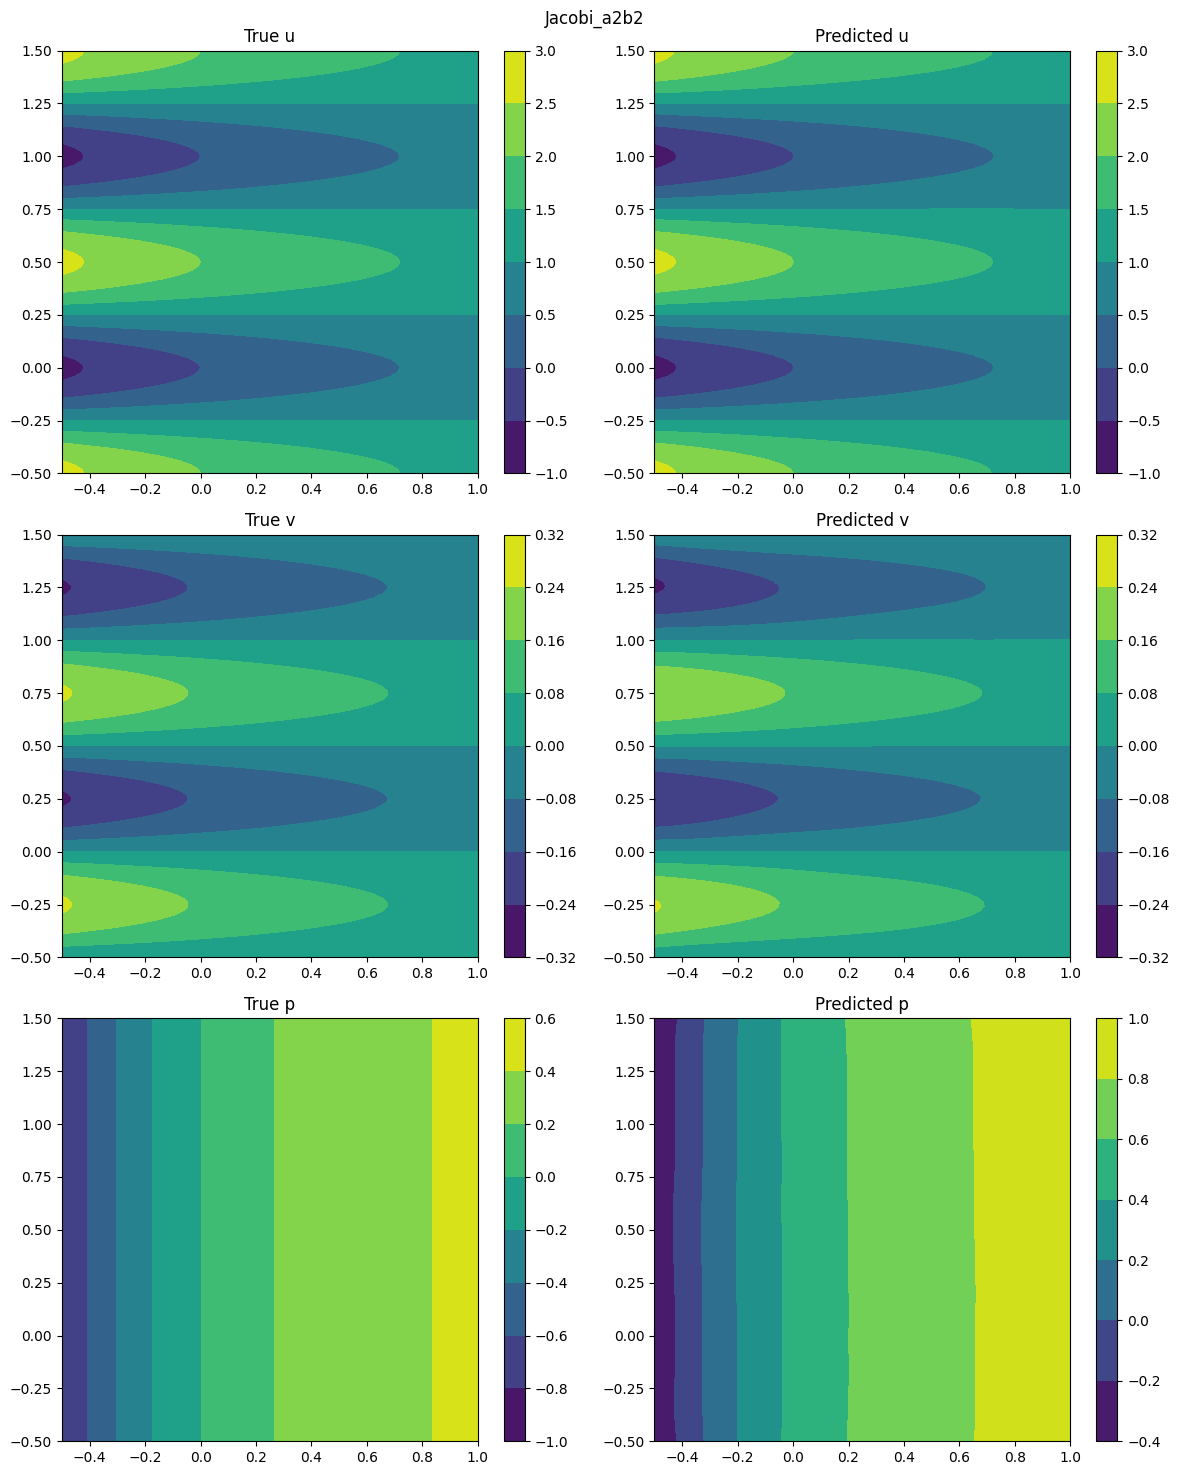


Training Jacobi_a1b1 model...
Jacobi_a1b1 total parameters: 5250
=====================Adam started===========================
Epoch 0, Loss: 1.41722e+00, Error: 9.58716e-01
Epoch 100, Loss: 1.66088e-01, Error: 4.95398e-01
Epoch 200, Loss: 9.35887e-02, Error: 3.56393e-01
=====================L-BFGS started===========================
Iter 0, Loss: 9.42342e-02, Error: 3.54363e-01
Iter 100, Loss: 2.96968e-03, Error: 3.49302e-02
Iter 200, Loss: 8.66245e-04, Error: 1.45912e-02
Iter 300, Loss: 3.75214e-04, Error: 8.49775e-03
Iter 400, Loss: 1.78568e-04, Error: 4.32515e-03
Iter 500, Loss: 1.19368e-04, Error: 3.17883e-03
Iter 600, Loss: 8.25739e-05, Error: 2.56504e-03


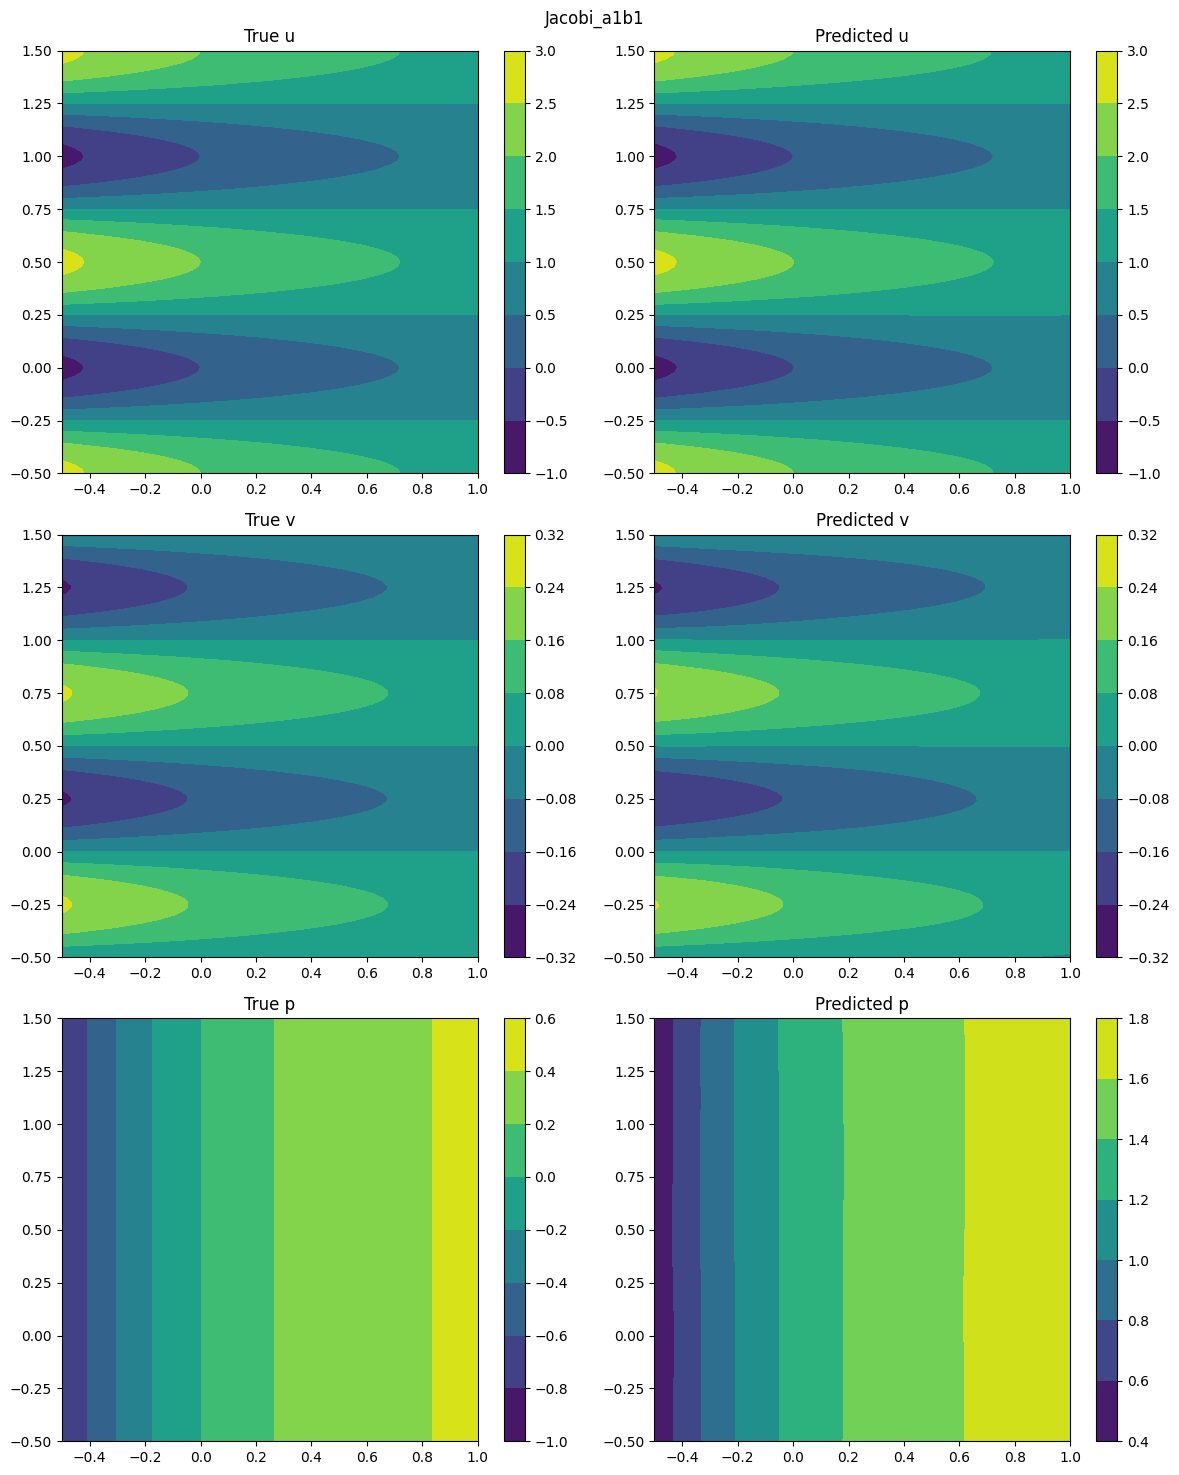


Training hermite model...
hermite total parameters: 5250
=====================Adam started===========================
Epoch 0, Loss: 1.27283e+01, Error: 1.05754e+00
Epoch 100, Loss: 9.94448e-02, Error: 2.97730e-01
Epoch 200, Loss: 3.47771e-02, Error: 1.24946e-01
=====================L-BFGS started===========================
Iter 0, Loss: 3.50000e-02, Error: 1.24934e-01
Iter 100, Loss: 8.59728e-03, Error: 6.14347e-02
Iter 200, Loss: 3.97389e-03, Error: 4.34716e-02
Iter 300, Loss: 2.21500e-03, Error: 2.80278e-02
Iter 400, Loss: 1.31073e-03, Error: 2.03144e-02
Iter 500, Loss: 8.68176e-04, Error: 1.51897e-02
Iter 600, Loss: 6.25472e-04, Error: 1.15341e-02
Iter 700, Loss: 4.62942e-04, Error: 9.38541e-03
Iter 800, Loss: 3.51959e-04, Error: 7.80739e-03


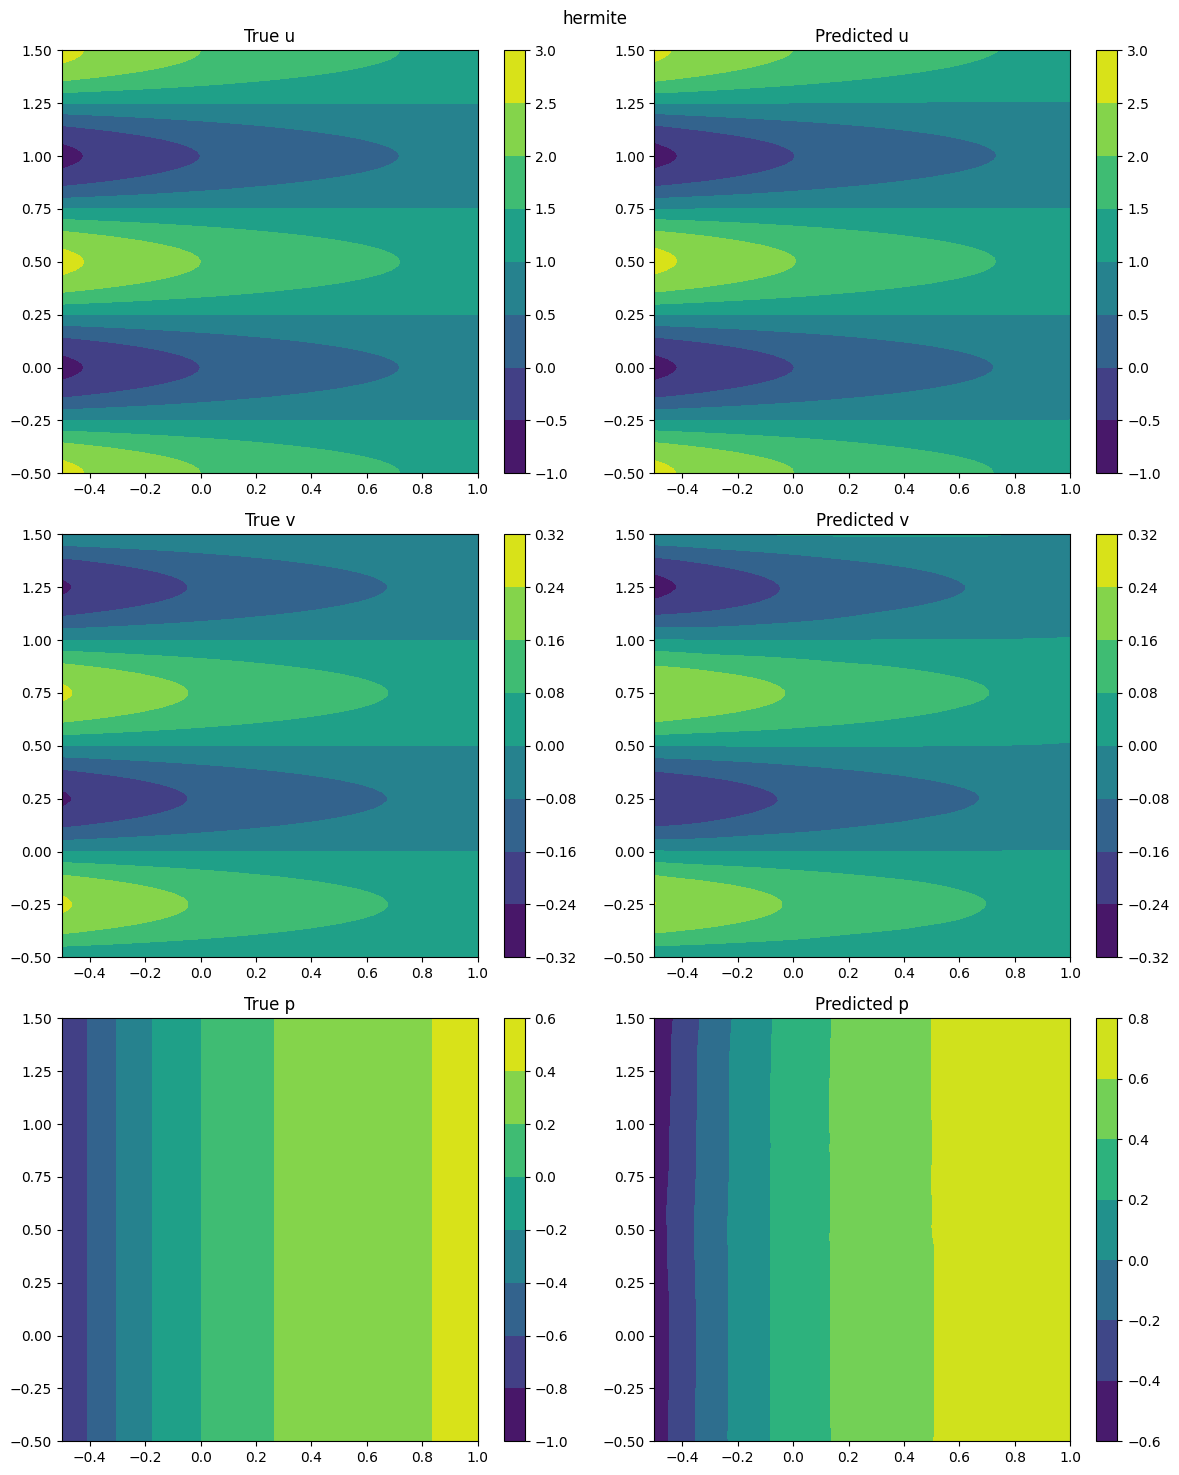


Training legendre model...
legendre total parameters: 5250
=====================Adam started===========================
Epoch 0, Loss: 1.26281e+00, Error: 9.18266e-01
Epoch 100, Loss: 1.77610e-01, Error: 4.84008e-01
Epoch 200, Loss: 4.86757e-02, Error: 2.35201e-01
=====================L-BFGS started===========================
Iter 0, Loss: 4.67736e-02, Error: 2.32222e-01
Iter 100, Loss: 3.07062e-03, Error: 4.57867e-02
Iter 200, Loss: 1.07741e-03, Error: 2.17995e-02
Iter 300, Loss: 4.24728e-04, Error: 1.31951e-02
Iter 400, Loss: 1.81500e-04, Error: 6.67630e-03


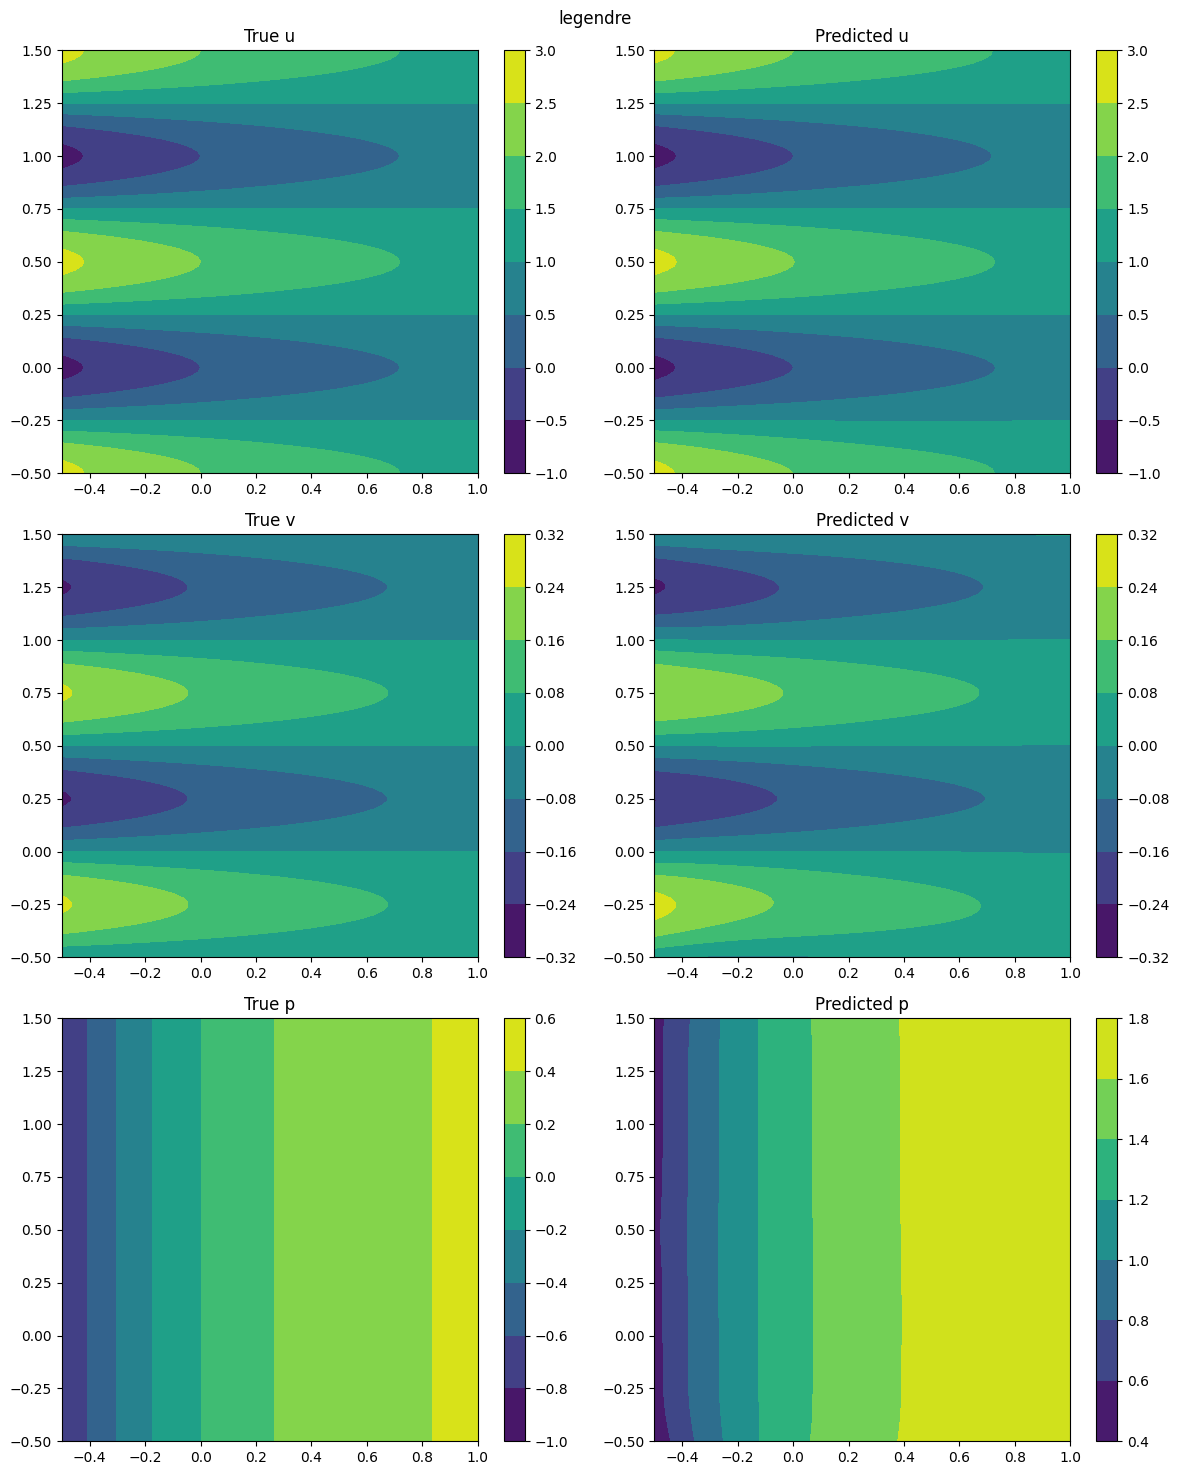


Training chebyshev model...
chebyshev total parameters: 5250
=====================Adam started===========================
Epoch 0, Loss: 1.33655e+00, Error: 8.90614e-01
Epoch 100, Loss: 1.02091e-01, Error: 3.68526e-01
Epoch 200, Loss: 2.89651e-02, Error: 1.66167e-01
=====================L-BFGS started===========================
Iter 0, Loss: 2.65236e-02, Error: 1.60594e-01
Iter 100, Loss: 1.65957e-03, Error: 1.96385e-02
Iter 200, Loss: 4.23104e-04, Error: 9.08770e-03
Iter 300, Loss: 1.77211e-04, Error: 5.24837e-03


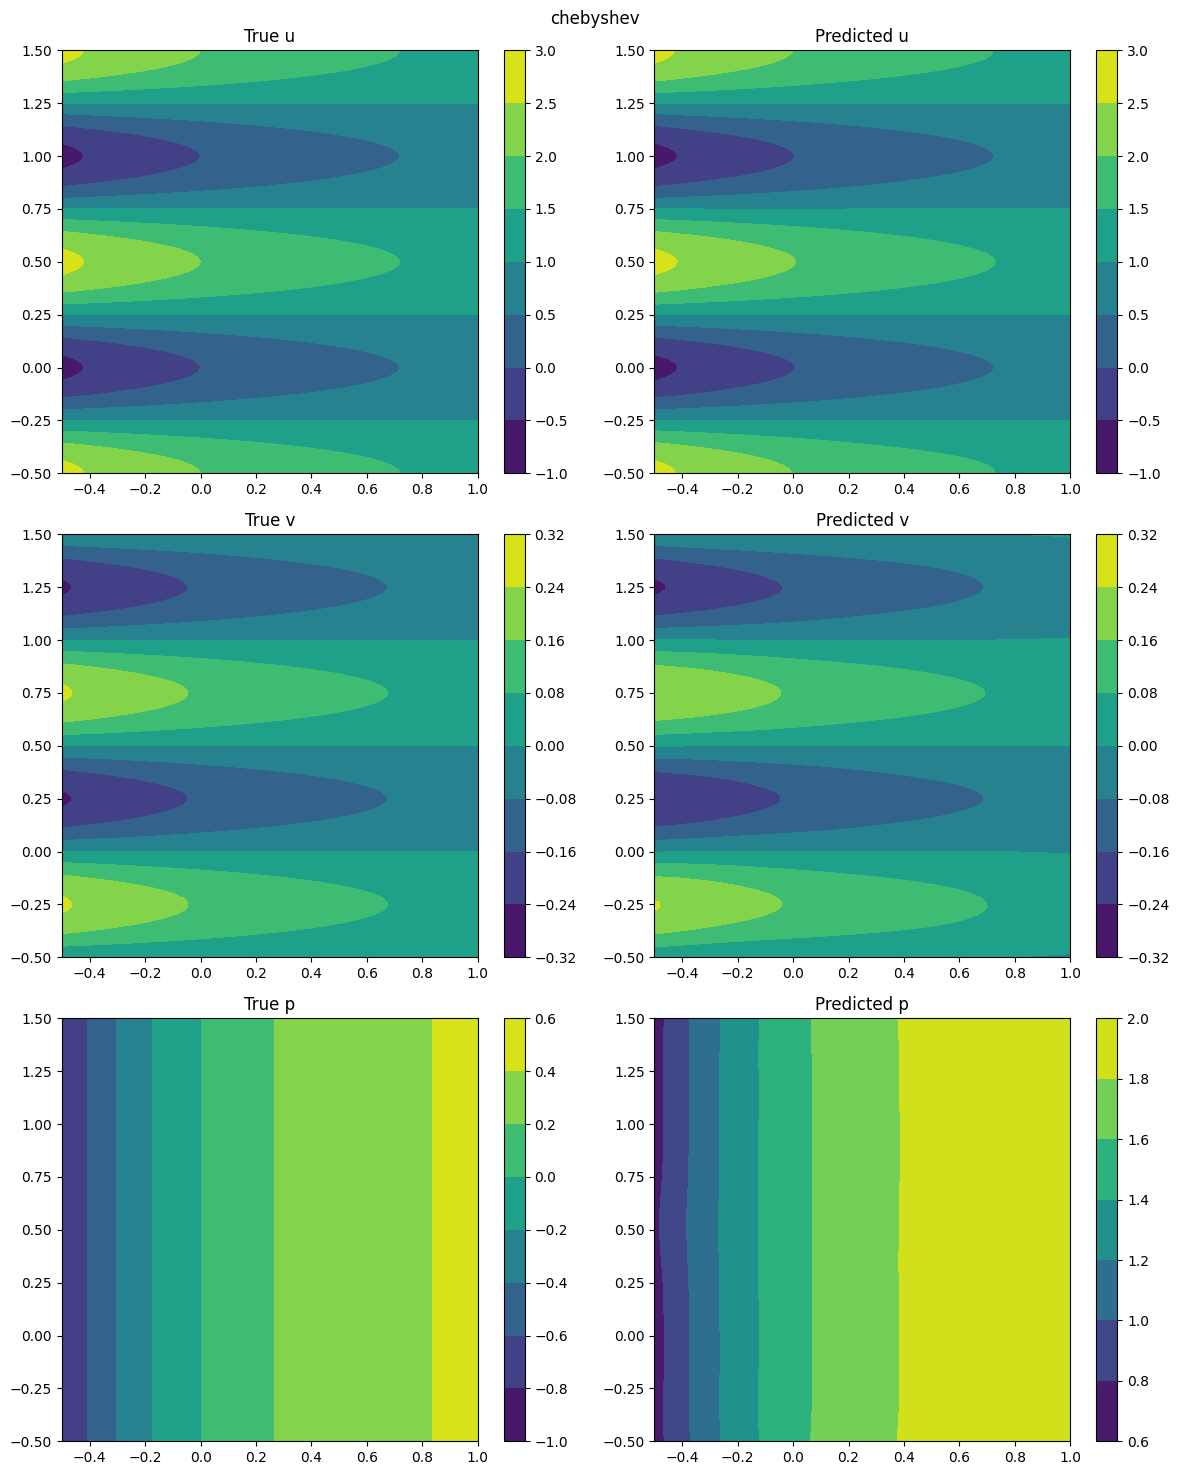

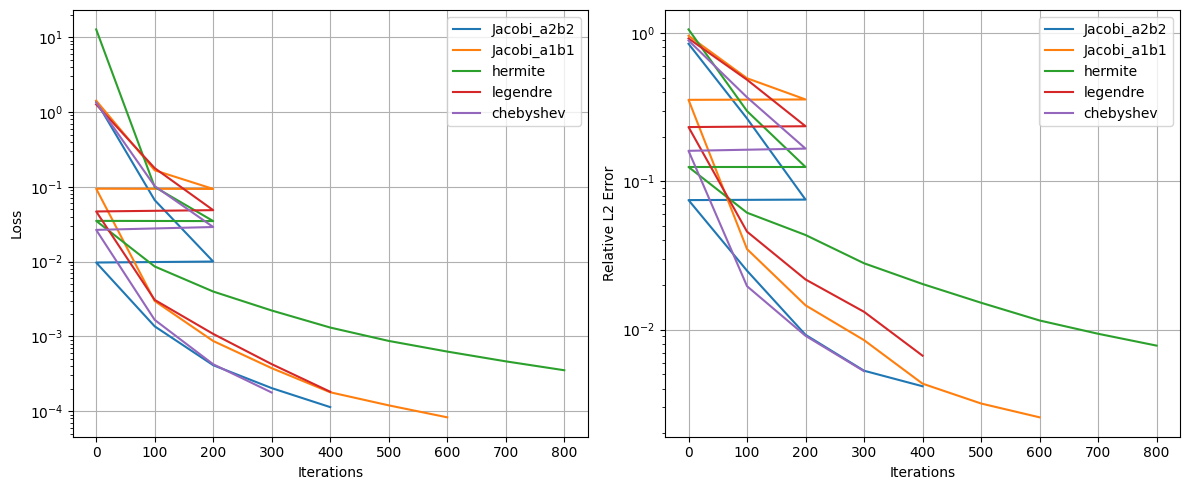

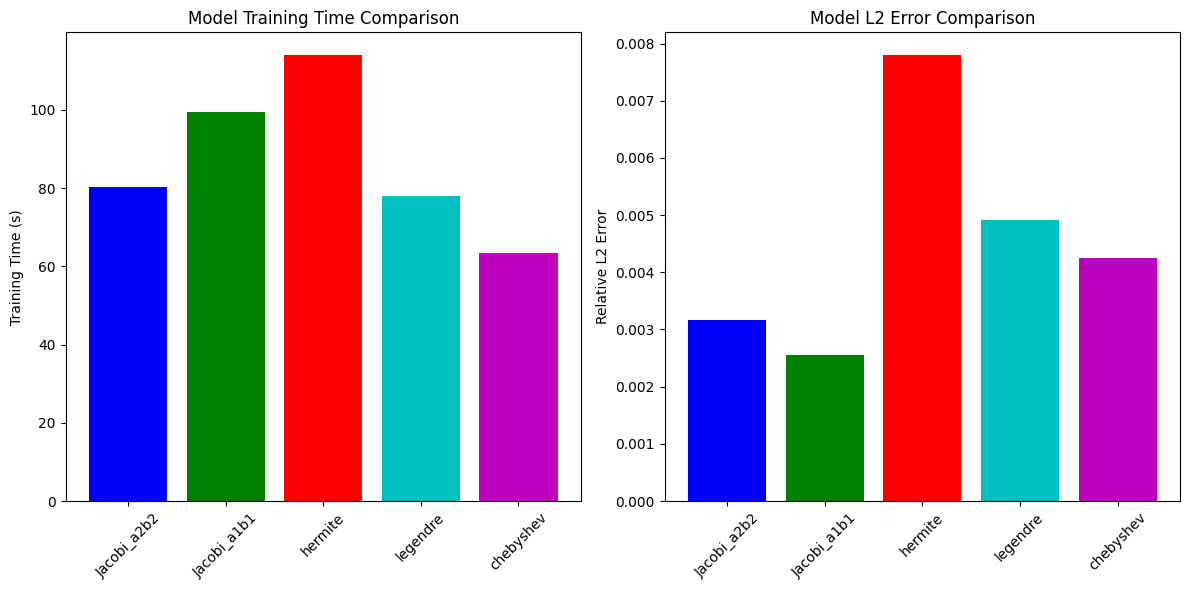


Final Results:
------------------------------------------------------------
Model                Training Time(s)     L2 Error       
------------------------------------------------------------
Jacobi_a2b2                         80.17       3.162e-03
Jacobi_a1b1                         99.43       2.557e-03
hermite                            114.10       7.806e-03
legendre                            77.87       4.914e-03
chebyshev                           63.41       4.251e-03

Results saved to Kovasznay_Jacobi_lbfgs_results_hidden2_size30_deg4.mat


In [6]:
def main():
    # Parameter settings
    equation = 'Kovasznay_Jacobi'
    nu = 1/40  # Viscosity coefficient
    degree = 4  # Basis function degree
    size = 30   # Number of neurons per layer
    hidden_layer = 2  # Number of hidden layers
    layers = [2] + [size] * hidden_layer + [3]  # Network structure
    epoch_ADAM = 202
    epoch_LBFGS = 802

    # Generate training and test data
    X_b, UV_b, X_f = generate_training_data()
    X_test, UV_test, p_test, X_mesh, Y_mesh = generate_test_data()

    # Define Jacobi model dictionary
    models_dict = OrderedDict({
        'Jacobi_a2b2': JacobiPINN2,
        'Jacobi_a1b1': JacobiPINN1,
        'hermite': HermitePINN,
        'legendre': LegendrePINN,
        'chebyshev': ChebyPINN,
    })

    # Store results
    results = {
        'training_time': {},
        'l2_error': {},
        'predictions': {},
        'loss_history': {},
        'error_history': {},
        'iter_history': {}
    }

    print(f"Network architecture: {layers}")

    # Train all Jacobi models
    for model_name, model_class in models_dict.items():
        print(f"\nTraining {model_name} model...")

        start_time = time.time()
        model = PhysicsInformedNN(X_b, UV_b, X_f, layers, nu, model_class, degree, epoch_LBFGS)
        print(f"{model_name} total parameters: {model.total_params}")

        # Training
        model.train_adam(epoch_ADAM, X_test, UV_test)
        model.train_lbfgs(X_test, UV_test)

        # Record results
        training_time = time.time() - start_time
        results['training_time'][model_name] = training_time

        # Prediction and error calculation
        u_pred, v_pred, p_pred = model.predict(X_test)
        error = model.compute_error(X_test, UV_test)
        results['l2_error'][model_name] = error

        # Store prediction results
        results['predictions'][model_name] = (u_pred, v_pred, p_pred)
        results['loss_history'][model_name] = model.loss_history
        results['error_history'][model_name] = model.error_history
        results['iter_history'][model_name] = model.iter_history

        # Plot results
        u_true, v_true, p_true = kovasznay_solution(X_test[:,0:1], X_test[:,1:2])
        plot_results(X_mesh, Y_mesh,
                    u_true, v_true, p_true,
                    u_pred.cpu().numpy(), v_pred.cpu().numpy(), p_pred.cpu().numpy(),
                    model_name, equation, size, hidden_layer, degree)

    # Plot training history
    plt.figure(figsize=(12, 5))

    # Loss history
    plt.subplot(121)
    for model_name in models_dict.keys():
        plt.semilogy(results['iter_history'][model_name],
                    results['loss_history'][model_name],
                    label=model_name)
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Error history
    plt.subplot(122)
    for model_name in models_dict.keys():
        plt.semilogy(results['iter_history'][model_name],
                    results['error_history'][model_name],
                    label=model_name)
    plt.xlabel('Iterations')
    plt.ylabel('Relative L2 Error')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'{equation}_training_history_size{size}_hidden{hidden_layer}_deg{degree}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Plot comparison
    from matplotlib import font_manager
    font_properties = font_manager.FontProperties(weight='bold')

    line_styles = ['-', '--', '-.', ':']
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'purple']

    plt.figure(figsize=(12, 6))

    plt.subplot(121)
    plt.bar(results['training_time'].keys(),
            results['training_time'].values(),
            color=colors[:len(results['training_time'])])
    plt.xticks(rotation=45)
    plt.title('Model Training Time Comparison')
    plt.ylabel('Training Time (s)')

    plt.subplot(122)
    plt.bar(results['l2_error'].keys(),
            results['l2_error'].values(),
            color=colors[:len(results['l2_error'])])
    plt.xticks(rotation=45)
    plt.title('Model L2 Error Comparison')
    plt.ylabel('Relative L2 Error')

    plt.tight_layout()
    plt.savefig(f'{equation}_time_error_comparison_size{size}_hidden{hidden_layer}_deg{degree}.png',
                dpi=300)
    plt.show()

    # Print final results
    print("\nFinal Results:")
    print("-" * 60)
    print(f"{'Model':<20} {'Training Time(s)':<20} {'L2 Error':<15}")
    print("-" * 60)
    for model_name in models_dict.keys():
        print(f"{model_name:<20} {results['training_time'][model_name]:>20.2f} {results['l2_error'][model_name]:>15.3e}")

    # Save results
    u_true, v_true, p_true = kovasznay_solution(X_test[:,0:1], X_test[:,1:2])

    scipy.io.savemat(f'{equation}_lbfgs_results_hidden{hidden_layer}_size{size}_deg{degree}.mat', {
        'X_mesh': X_mesh,
        'Y_mesh': Y_mesh,
        'u_true': u_true,
        'v_true': v_true,
        'p_true': p_true,
        'predictions': {name: {
            'u': results['predictions'][name][0].cpu().numpy(),
            'v': results['predictions'][name][1].cpu().numpy(),
            'p': results['predictions'][name][2].cpu().numpy()
        } for name in results['predictions'].keys()},
        'training_time': results['training_time'],
        'l2_error': results['l2_error'],
        'loss_history': results['loss_history'],
        'error_history': results['error_history'],
        'iter_history': results['iter_history']
    })

    print(f"\nResults saved to {equation}_lbfgs_results_hidden{hidden_layer}_size{size}_deg{degree}.mat")

if __name__ == '__main__':
    main()

### **Resultados**

**Convergência dos Modelos**

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_training_history_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Convergencia dos Modelos." width="1100"><br>
  <em>Fluxo Kovasznay Convergencia dos Modelos</em>
</div>

**Comparação de Tempo e Erro**
<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_time_error_comparison_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Comparação de tempo e erro L2." width="900"><br>
  <em>Fluxo Kovasznay Comparação de tempo e erro L2</em>
</div>



**Jacobi** $\alpha = \beta = 1$

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_Jacobi_a1b1_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Jacobi(1,1)." width="900"><br>
  <em>Fluxo Kovasznay Jacobi(1,1)</em>
</div>

**Jacobi** $\alpha = \beta = 2$

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_Jacobi_a2b2_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Jacobi(2,2)." width="900"><br>
  <em>Fluxo Kovasznay Jacobi(2,2)</em>
</div>


**Chebyshev: Jacobi** $\alpha = \beta = -0.5$

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_chebyshev_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Chebyshev." width="900"><br>
  <em>Fluxo Kovasznay Chebyshev</em>
</div>

**Legendre: Jacobi** $\alpha = \beta = 0$

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_legendre_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Legendre." width="900"><br>
  <em>Fluxo Kovasznay Legendre</em>
</div>


**Hermite**

<div align="center">
  <img src="https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/images/Kovasznay_Jacobi_size30_hidden2_deg4/Kovasznay_Jacobi_hermite_size30_hidden2_deg4.png" alt = "Fluxo Kovasznay Hermite." width="900"><br>
  <em>Fluxo Kovasznay Hermite</em>
</div>

In [4]:
import urllib.request
from scipy.io import loadmat

url = "https://raw.githubusercontent.com/Paulo-de-Souza/PIML_OpInf/main/J-PIKAN/arquivos_mat/Kovasznay_Jacobi_lbfgs_results_hidden2_size30_deg4.mat"

urllib.request.urlretrieve(url, "arquivo.mat")

dados = loadmat("arquivo.mat")
print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X_mesh', 'Y_mesh', 'u_true', 'v_true', 'p_true', 'predictions', 'training_time', 'l2_error', 'loss_history', 'error_history', 'iter_history'])


In [5]:
print(dados["l2_error"])

[[(array([[0.00316208]]), array([[0.00255655]]), array([[0.00780595]]), array([[0.00491394]]), array([[0.00425107]]))]]


### `JacobiPINN_taylor2D_NS.py`

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pydoe import lhs
import scipy.io
import time
from collections import OrderedDict

from scipy.interpolate import griddata

# Import Jacobi models
from KAN_nn.jacobi_a2b2 import JacobiPINN2
from KAN_nn.jacobi_a1b1 import JacobiPINN1

# Check CUDA device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)


class PhysicsInformedNN:
    def __init__(self, X_data, UV_data, X_f, layers, nu, nn_model, degree, epoch_LBFGS):
        self.epoch_LBFGS = epoch_LBFGS

        # Record training history
        self.loss_history = []
        self.error_history = []
        self.iter_history = []

        # Data processing
        self.X_data = torch.tensor(X_data, requires_grad=True).float().to(device)
        self.UV_data = torch.tensor(UV_data).float().to(device)
        self.X_f = torch.tensor(X_f, requires_grad=True).float().to(device)
        self.nu = nu

        # Initialize model
        self.dnn = nn_model(layers, degree).to(device)
        self.total_params = sum(p.numel() for p in self.dnn.parameters())

        # Optimizers
        self.optimizer_adam = optim.Adam(self.dnn.parameters(), lr=1e-3)
        self.optimizer_lbfgs = optim.LBFGS(
            self.dnn.parameters(),
            lr=1.0,
            max_iter=self.epoch_LBFGS,
            max_eval=self.epoch_LBFGS,
            history_size=50,
            tolerance_grad=1e-5,
            tolerance_change=1e-7,
            line_search_fn="strong_wolfe"
        )
        self.iter = 0

    def net_uvp(self, x):

        uvp = self.dnn(x)

        u = uvp[:,0:1]
        v = uvp[:,1:2]
        p = uvp[:,2:3]

        return u,v,p

    def net_f(self, x):
        """Compute PDE residuals"""
        u, v, p = self.net_uvp(x)

        # Compute partial derivatives
        u_t = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 2:3]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 0:1]
        u_y = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0][:, 1:2]

        u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
        u_yy = torch.autograd.grad(u_y, x, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]

        v_t = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 2:3]
        v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 0:1]
        v_y = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0][:, 1:2]

        v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
        v_yy = torch.autograd.grad(v_y, x, grad_outputs=torch.ones_like(v_y), create_graph=True)[0][:, 1:2]

        p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0][:, 0:1]
        p_y = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0][:, 1:2]

        # Navier-Stokes equations
        f_u = u_t + (u*u_x + v*u_y) + p_x - self.nu*(u_xx + u_yy)
        f_v = v_t + (u*v_x + v*v_y) + p_y - self.nu*(v_xx + v_yy)
        f_p = u_x + v_y

        return f_u, f_v, f_p

    def loss_func(self):
        """Compute total loss"""
        # Predictions
        u_pred, v_pred, _ = self.net_uvp(self.X_data)
        UV_pred = torch.cat([u_pred, v_pred], dim=1)

        # Data loss
        loss_data = torch.mean((UV_pred - self.UV_data)**2)

        # PDE residual loss
        f_u, f_v, f_p = self.net_f(self.X_f)
        loss_pde = torch.mean(f_u**2 + f_v**2 + f_p**2)

        return loss_data + loss_pde


    def train_adam(self, epochs, X_test, UV_test):
        print("=====================Adam started===========================")
        self.dnn.train()
        for epoch in range(epochs):
            self.optimizer_adam.zero_grad()
            loss = self.loss_func()
            loss.backward()
            self.optimizer_adam.step()

            if epoch % 100 == 0:
                error = self.compute_error(X_test, UV_test)
                print(f"Epoch {epoch}, Loss: {loss.item():.5e}, Error: {error:.5e}")
                self.loss_history.append(loss.item())
                self.error_history.append(error)
                self.iter_history.append(epoch)

    def train_lbfgs(self, X_test, UV_test, epoch_ADAM):
        print("=====================L-BFGS started===========================")
        self.dnn.train()

        def closure():
            self.optimizer_lbfgs.zero_grad()
            loss = self.loss_func()
            loss.backward()
            if self.iter % 100 == 0:
                error = self.compute_error(X_test, UV_test)
                print(f"Iter {self.iter}, Loss: {loss.item():.5e}, Error: {error:.5e}")
                self.loss_history.append(loss.item())
                self.error_history.append(error)
                self.iter_history.append(self.iter + epoch_ADAM)
            self.iter += 1
            return loss

        self.optimizer_lbfgs.step(closure)

    def predict(self, X):
        """Model prediction"""
        X = torch.tensor(X, dtype=torch.float32).to(device)
        self.dnn.eval()
        with torch.no_grad():
            return self.net_uvp(X)

    def compute_error(self, X_test, UV_test):
        """Compute prediction error"""
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        UV_test = torch.tensor(UV_test, dtype=torch.float32).to(device)

        u_pred, v_pred, _ = self.predict(X_test)
        UV_pred = torch.cat([u_pred, v_pred], dim=1)

        error = torch.norm(UV_test - UV_pred, 2) / torch.norm(UV_test, 2)
        return error.item()

def load_and_process_data(data_path, n_f=10000):
    """
    Load and process Navier-Stokes equation data
    """
    # Load data
    data = scipy.io.loadmat(data_path)

    # Get grid data
    x = data['x'].flatten()
    y = data['y'].flatten()
    t = data['t'].flatten()

    X, Y, T = np.meshgrid(x, y, t, indexing='ij')

    u = data['u']
    v = data['v']
    p = data['p']

    nx, ny, nt = u.shape

    # Initial condition data
    idx_t0 = 0
    X_ic = np.hstack((
        X[:, :, idx_t0].flatten()[:, None],
        Y[:, :, idx_t0].flatten()[:, None],
        T[:, :, idx_t0].flatten()[:, None]
    ))
    UV_ic = np.hstack((
        u[:, :, idx_t0].flatten()[:, None],
        v[:, :, idx_t0].flatten()[:, None]
    ))

    # Boundary condition data
    # Left boundary
    X_bc_left = np.hstack((
        X[0, :, :].flatten()[:, None],
        Y[0, :, :].flatten()[:, None],
        T[0, :, :].flatten()[:, None]
    ))
    UV_bc_left = np.hstack((
        u[0, :, :].flatten()[:, None],
        v[0, :, :].flatten()[:, None]
    ))

    # Right boundary
    X_bc_right = np.hstack((
        X[-1, :, :].flatten()[:, None],
        Y[-1, :, :].flatten()[:, None],
        T[-1, :, :].flatten()[:, None]
    ))
    UV_bc_right = np.hstack((
        u[-1, :, :].flatten()[:, None],
        v[-1, :, :].flatten()[:, None]
    ))

    # Bottom boundary
    X_bc_bottom = np.hstack((
        X[:, 0, :].flatten()[:, None],
        Y[:, 0, :].flatten()[:, None],
        T[:, 0, :].flatten()[:, None]
    ))
    UV_bc_bottom = np.hstack((
        u[:, 0, :].flatten()[:, None],
        v[:, 0, :].flatten()[:, None]
    ))

    # Top boundary
    X_bc_top = np.hstack((
        X[:, -1, :].flatten()[:, None],
        Y[:, -1, :].flatten()[:, None],
        T[:, -1, :].flatten()[:, None]
    ))
    UV_bc_top = np.hstack((
        u[:, -1, :].flatten()[:, None],
        v[:, -1, :].flatten()[:, None]
    ))

    # Merge all boundary and initial condition data
    X_data = np.vstack([X_ic, X_bc_left, X_bc_right, X_bc_bottom, X_bc_top])
    print("X_data", X_data.shape)
    UV_data = np.vstack([UV_ic, UV_bc_left, UV_bc_right, UV_bc_bottom, UV_bc_top])
    print("UV_data", UV_data.shape)

    # Sample interior points
    lb = np.array([x.min(), y.min(), t.min()])
    ub = np.array([x.max(), y.max(), t.max()])
    X_f = lb + (ub - lb) * lhs(3, n_f)

    # Prepare test data
    X_test = np.hstack((
        X.flatten()[:, None],
        Y.flatten()[:, None],
        T.flatten()[:, None]
    ))
    UV_test = np.hstack((
        u.flatten()[:, None],
        v.flatten()[:, None]
    ))
    P_test = p.flatten()[:, None]

    return X_data, UV_data, X_f, X_test, UV_test, P_test, lb, ub


device: cpu


In [ ]:
def main():
    # Set parameters
    equation = 'NS_degree4_jacobi'
    data_path = 'data/NS_Taylor_Green_mu_0.01.mat'
    nu = 0.01  # Viscosity coefficient
    n_f = 2000  # Number of collocation points

    # Load and process data
    print("Loading and processing data...")
    X_data, UV_data, X_f, X_test, UV_test, P_test, lb, ub = load_and_process_data(data_path, n_f)
    print(f"Data loading completed!")
    print(f"Training data points: {len(X_data)}")
    print(f"Collocation points: {len(X_f)}")
    print(f"Test points: {len(X_test)}")

    # Define Jacobi model dictionary
    models_dict = OrderedDict({
        'Jacobi(alpha=2,beta=2)': JacobiPINN2,
        'Jacobi(alpha=1,beta=1)': JacobiPINN1,
    })

    # Store results
    results = {
        'training_time': {},
        'l2_error': {},
        'predictions': {},
        'loss_history': {},
        'error_history': {},
        'iter_history': {}
    }

    # Training parameters
    epoch_ADAM = 2000
    epoch_LBFGS = 20000

    degree = 4
    size = 20
    hidden_layer = 4
    layers = [3] + [size] * hidden_layer + [3]
    print(f"Network architecture: {layers}")

    # Train all Jacobi models
    for model_name, model_class in models_dict.items():
        print(f"\nTraining {model_name} model...")

        start_time = time.time()
        model = PhysicsInformedNN(X_data, UV_data, X_f, layers, nu,
                                 model_class, degree, epoch_LBFGS)

        print(f"{model_name} total parameters: {model.total_params}")

        # Training
        model.train_adam(epoch_ADAM, X_test, UV_test)
        model.train_lbfgs(X_test, UV_test, epoch_ADAM)

        # Record results
        training_time = time.time() - start_time
        results['training_time'][model_name] = training_time

        # Prediction and error calculation
        UV_pred = model.predict(X_test)
        error = model.compute_error(X_test, UV_test)
        results['l2_error'][model_name] = error

        # Store other results
        results['predictions'][model_name] = UV_pred
        results['loss_history'][model_name] = model.loss_history
        results['error_history'][model_name] = model.error_history
        results['iter_history'][model_name] = model.iter_history

    # Load data for visualization
    data = scipy.io.loadmat(data_path)
    x = data['x'].flatten()
    y = data['y'].flatten()
    t = data['t'].flatten()
    X, Y = np.meshgrid(x, y)
    u = data['u']
    v = data['v']
    p = data['p']

    # Save prediction data
    file_name = f'{equation}_model_predictions_size_{size}_hidden_layer_{hidden_layer}_degree_{degree}.npz'
    np.savez(file_name,
             predictions=results['predictions'],
             l2_error=results['l2_error'])

    # Prediction visualization
    t_idx = 50
    t_val = t[t_idx]

    # Get ground truth at this time
    u_true = u[:, :, t_idx]
    v_true = v[:, :, t_idx]
    p_true = p[:, :, t_idx]

    # Create grid points
    x_grid = np.linspace(x.min(), x.max(), 256)
    y_grid = np.linspace(y.min(), y.max(), 256)
    X_mesh, Y_mesh = np.meshgrid(x_grid, y_grid)

    # Create figure for each model with u, v, p subplots
    for model_name, pred_tuple in results['predictions'].items():
        fig = plt.figure(figsize=(20, 6))

        # Extract and reshape predictions
        u_pred = pred_tuple[0].cpu().numpy()
        v_pred = pred_tuple[1].cpu().numpy()
        p_pred = pred_tuple[2].cpu().numpy()

        # Reshape to 3D array [nx, ny, nt]
        nx = ny = int(np.sqrt(u_pred.shape[0] / len(t)))
        u_pred_3d = u_pred.reshape(nx, ny, len(t))
        v_pred_3d = v_pred.reshape(nx, ny, len(t))
        p_pred_3d = p_pred.reshape(nx, ny, len(t))

        # Extract predictions at specific time
        u_pred_t = u_pred_3d[:, :, t_idx]
        v_pred_t = v_pred_3d[:, :, t_idx]
        p_pred_t = p_pred_3d[:, :, t_idx]

        # Compute relative errors
        error_u = np.linalg.norm(u_true - u_pred_t) / np.linalg.norm(u_true)
        error_v = np.linalg.norm(v_true - v_pred_t) / np.linalg.norm(v_true)
        error_p = np.linalg.norm(p_true - p_pred_t) / np.linalg.norm(p_true)

        # u component
        plt.subplot(131)
        c = plt.pcolor(X_mesh, Y_mesh, u_pred_t, cmap='rainbow')
        plt.colorbar(c)
        plt.title(f'u - Error: {error_u:.3e}')
        plt.xlabel('x', fontsize=12, fontweight='bold')
        plt.ylabel('y', fontsize=12, fontweight='bold')
        plt.grid(True)

        # v component
        plt.subplot(132)
        c = plt.pcolor(X_mesh, Y_mesh, v_pred_t, cmap='rainbow')
        plt.colorbar(c)
        plt.title(f'v - Error: {error_v:.3e}')
        plt.xlabel('x', fontsize=12, fontweight='bold')
        plt.ylabel('y', fontsize=12, fontweight='bold')
        plt.grid(True)

        # p component
        plt.subplot(133)
        c = plt.pcolor(X_mesh, Y_mesh, p_pred_t, cmap='rainbow')
        plt.colorbar(c)
        plt.title(f'p - Error: {error_p:.3e}')
        plt.xlabel('x', fontsize=12, fontweight='bold')
        plt.ylabel('y', fontsize=12, fontweight='bold')
        plt.grid(True)

        plt.suptitle(f'Model: {model_name} at t = {t_val:.2f}', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'{equation}_{model_name}_prediction_t{t_idx}_size_{size}_hidden_layer_{hidden_layer}_degree_{degree}.png',
                    dpi=300, bbox_inches='tight')
        plt.show()

    # Plot ground truth
    fig = plt.figure(figsize=(20, 6))

    plt.subplot(131)
    c = plt.pcolor(X_mesh, Y_mesh, u_true, cmap='rainbow')
    plt.colorbar(c)
    plt.title('u')
    plt.xlabel('x', fontsize=12, fontweight='bold')
    plt.ylabel('y', fontsize=12, fontweight='bold')
    plt.grid(True)

    plt.subplot(132)
    c = plt.pcolor(X_mesh, Y_mesh, v_true, cmap='rainbow')
    plt.colorbar(c)
    plt.title('v')
    plt.xlabel('x', fontsize=12, fontweight='bold')
    plt.ylabel('y', fontsize=12, fontweight='bold')
    plt.grid(True)

    plt.subplot(133)
    c = plt.pcolor(X_mesh, Y_mesh, p_true, cmap='rainbow')
    plt.colorbar(c)
    plt.title('p')
    plt.xlabel('x', fontsize=12, fontweight='bold')
    plt.ylabel('y', fontsize=12, fontweight='bold')
    plt.grid(True)

    plt.suptitle(f'Ground Truth at t = {t_val:.2f}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{equation}_ground_truth_t{t_idx}_size_{size}_hidden_layer_{hidden_layer}_degree_{degree}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Save error data to text file
    output_file_name = f"{equation}_model_comparison_results_t{t_idx}_size_{size}_hidden_layer_{hidden_layer}_degree_{degree}.txt"
    with open(output_file_name, 'w') as f:
        f.write(f"\nResults at t = {t_val:.2f}:\n")
        f.write("-" * 90 + "\n")
        f.write(f"{'Model Name':<25} {'Training Time(s)':<18} {'Error u':<12} {'Error v':<12} {'Error p':<12} {'Avg Error':<12}\n")
        f.write("-" * 90 + "\n")
        for model_name in models_dict.keys():
            pred_tuple = results['predictions'][model_name]
            u_pred = pred_tuple[0].cpu().numpy().reshape(nx, ny, len(t))[:, :, t_idx]
            v_pred = pred_tuple[1].cpu().numpy().reshape(nx, ny, len(t))[:, :, t_idx]
            p_pred = pred_tuple[2].cpu().numpy().reshape(nx, ny, len(t))[:, :, t_idx]

            error_u = np.linalg.norm(u_true - u_pred) / np.linalg.norm(u_true)
            error_v = np.linalg.norm(v_true - v_pred) / np.linalg.norm(v_true)
            error_p = np.linalg.norm(p_true - p_pred) / np.linalg.norm(p_true)
            total_error = (error_u + error_v + error_p) / 3

            f.write(f"{model_name:<25} {results['training_time'][model_name]:<18.2f} "
                    f"{error_u:<12.3e} {error_v:<12.3e} {error_p:<12.3e} {total_error:<12.3e}\n")

    # Set bold font
    from matplotlib import font_manager
    font_properties = font_manager.FontProperties(weight='bold')

    # Save training history
    file_name = f'{equation}_model_training_results_size_{size}_hidden_layer_{hidden_layer}.npz'
    np.savez(file_name,
             iter_history=results['iter_history'],
             loss_history=results['loss_history'],
             error_history=results['error_history'])

    # Plot training history
    plt.figure(figsize=(15, 6))
    line_styles = ['-', '--', '-.', ':']
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'purple']
    font_properties = font_manager.FontProperties(weight='bold')

    # Loss history
    plt.subplot(121)
    for i, model_name in enumerate(models_dict.keys()):
        plt.semilogy(results['iter_history'][model_name],
                     results['loss_history'][model_name],
                     label=model_name,
                     linestyle=line_styles[i % len(line_styles)],
                     color=colors[i % len(colors)],
                     linewidth=2)
    plt.xlabel('Iterations', fontsize=14, fontweight='bold')
    plt.ylabel('Loss', fontsize=14, fontweight='bold')
    plt.title('Training Loss History', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12, prop=font_properties)
    plt.grid(True)
    plt.tick_params(axis='both', which='major', labelsize=12, width=2)

    # Error history
    plt.subplot(122)
    for i, model_name in enumerate(models_dict.keys()):
        plt.semilogy(results['iter_history'][model_name],
                     results['error_history'][model_name],
                     label=model_name,
                     linestyle=line_styles[i % len(line_styles)],
                     color=colors[i % len(colors)],
                     linewidth=2)
    plt.xlabel('Iterations', fontsize=14, fontweight='bold')
    plt.ylabel('Relative L2 Error', fontsize=14, fontweight='bold')
    plt.title('Error History', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12, prop=font_properties)
    plt.grid(True)
    plt.tick_params(axis='both', which='major', labelsize=12, width=2)

    plt.tight_layout()
    plt.savefig(f'{equation}_training_history_size_{size}_hidden_layer_{hidden_layer}.png',
                dpi=300)
    plt.show()

    # Training time and error comparison
    file_name = f'{equation}_model_training_time_error_comparison_size_{size}_hidden_layer_{hidden_layer}.npz'
    np.savez(file_name,
             training_time=results['training_time'],
             l2_error=results['l2_error'])

    plt.figure(figsize=(12, 6))

    plt.subplot(121)
    plt.bar(results['training_time'].keys(),
            results['training_time'].values(),
            color=colors[:len(results['training_time'])])
    plt.xticks(rotation=45)
    plt.title('Model Training Time Comparison')
    plt.ylabel('Training Time (s)')

    plt.subplot(122)
    plt.bar(results['l2_error'].keys(),
            results['l2_error'].values(),
            color=colors[:len(results['l2_error'])])
    plt.xticks(rotation=45)
    plt.title('Model L2 Error Comparison')
    plt.ylabel('Relative L2 Error')

    plt.tight_layout()
    plt.savefig(f'{equation}_time_error_comparison_size_{size}_hidden_layer_{hidden_layer}.png',
                dpi=300)
    plt.show()

    # Save detailed results to text file
    output_file_name = f"{equation}_model_comparison_results_size_{size}_hidden_layer_{hidden_layer}.txt"
    with open(output_file_name, 'w') as f:
        f.write("\nDetailed Results Statistics:\n")
        f.write("-" * 60 + "\n")
        f.write(f"{'Model Name':<25} {'Training Time(s)':<18} {'L2 Error':<15}\n")
        f.write("-" * 60 + "\n")
        for model_name in models_dict.keys():
            f.write(f"{model_name:<25} {results['training_time'][model_name]:<18.2f} {results['l2_error'][model_name]:<15.3e}\n")

    # Print results
    print("\nDetailed Results Statistics:")
    print("-" * 60)
    print(f"{'Model Name':<25} {'Training Time(s)':<18} {'L2 Error':<15}")
    print("-" * 60)
    for model_name in models_dict.keys():
        print(f"{model_name:<25} {results['training_time'][model_name]:<18.2f} {results['l2_error'][model_name]:<15.3e}")


if __name__ == '__main__':
    main()